In [2]:
pip install minisom


Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for minisom: filename=minisom-2.3.6-py3-none-any.whl size=13181 sha256=1c38eae3d15145b2cfb932d2444cf9bedb789a51f7579c16619d3c6a51e973c2
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\84\35\b8\48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom
Note: you may need to restart the kernel to use updated packages.


In [3]:

pip install pillow


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


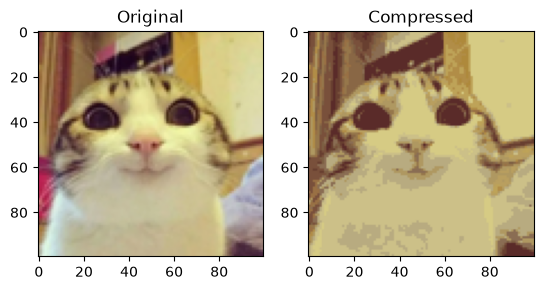

In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom

# Load image
image = Image.open("cat.webp")
image = image.resize((100,100))

# Convert image to array
pixels = np.array(image)
data = pixels.reshape(-1,3) / 255

# Create SOM
som = MiniSom(4,4,3,sigma=1.0,learning_rate=0.5)

# Train SOM
som.random_weights_init(data)
som.train_random(data,100)

# Compress image
new_pixels = []

for color in data:
    win = som.winner(color)
    new_pixels.append(som.get_weights()[win])

new_pixels = np.array(new_pixels)
new_pixels = (new_pixels*255).astype(np.uint8)

compressed = new_pixels.reshape(pixels.shape)

# Display images
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(compressed)
plt.title("Compressed")

plt.show()